In [16]:
from dotenv import load_dotenv
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, log_loss

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [17]:
if os.environ.get("ENV", "local") == "local":
    load_dotenv()

In [18]:
client = bigquery.Client.from_service_account_json(r'C:\Users\willb\Documents\Projetos\Projeto-Fiap-3\fiap-3-98eeb2f3a5d2.json')

In [19]:
query = """
        SELECT DISTINCT * 
        FROM `fiap-3.fut.dados_modelo_prev`
        --where rodada > 5
    """

In [20]:
df = client.query(query).to_dataframe().fillna(0)

c:\Users\willb\Documents\Projetos\Projeto-Fiap-3\venv_fiap3\lib\site-packages\google\cloud\bigquery\table.py:1957: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [21]:
df.columns

Index(['id_partida', 'team_id', 'opponent_id', 'rodada', 'flag_casa', 'result',
       'contextual_home_score_team', 'elo_team_rodada_anterior',
       'avg_total_goals_team', 'avg_total_goals_contra_team',
       'avg_total_shots_team', 'avg_shots_on_goal_team', 'avg_possession_team',
       'avg_expected_goals_team', 'contextual_home_score_opp',
       'elo_opp_rodada_anterior', 'avg_total_goals_opp',
       'avg_total_goals_contra_opp', 'avg_total_shots_opp',
       'avg_shots_on_goal_opp', 'avg_possession_opp', 'avg_expected_goals_opp',
       'form_score_weighted_team', 'form_score_weighted_opp'],
      dtype='object')

In [22]:
target = "result"


features = ['contextual_home_score_team', 'elo_team_rodada_anterior',
       'avg_total_goals_team', 'avg_total_goals_contra_team',
       'avg_total_shots_team', 'avg_shots_on_goal_team', 'avg_possession_team',
       'avg_expected_goals_team', 'contextual_home_score_opp',
       'elo_opp_rodada_anterior', 'avg_total_goals_opp',
       'avg_total_goals_contra_opp', 'avg_total_shots_opp',
       'avg_shots_on_goal_opp', 'avg_possession_opp', 'avg_expected_goals_opp',
       'form_score_weighted_team', 'form_score_weighted_opp']


In [23]:
features

# Aplica normalização
scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[features] = scaler.fit_transform(df[features])

In [24]:
X = df_normalized[features]
y = df_normalized[target]

In [25]:
# 🔹 7. Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

In [36]:
# Pipeline com SMOTE antes do classificador
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('classifier', RandomForestClassifier(random_state=42,max_depth = 15, min_samples_leaf= 2, min_samples_split= 10, n_estimators= 100, class_weight= 'balanced' ))
])

In [28]:

#Grid de hiperparâmetros
param_grid = {
    'classifier__n_estimators': [100,50,150, 200],
    'classifier__max_depth': [5, 10, None,3,8,15],
   'classifier__min_samples_split': [2,3,4, 5,8,10],
    'classifier__min_samples_leaf': [2,3,4,5,8,10]
}

In [29]:
from sklearn.model_selection import GridSearchCV
# GridSearch com 5 folds, usando treino (com SMOTE)
grid_search = GridSearchCV(pipeline, param_grid, cv=100, scoring='accuracy', n_jobs=-1, verbose=2)


In [30]:
grid_search.fit(X_train, y_train)

Fitting 100 folds for each of 864 candidates, totalling 86400 fits


GridSearchCV(cv=100,
             estimator=Pipeline(steps=[('smote',
                                        SMOTE(k_neighbors=3, random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               min_samples_leaf=2,
                                                               min_samples_split=10,
                                                               n_estimators=150,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None, 3, 8, 15],
                         'classifier__min_samples_leaf': [2, 3, 4, 5, 8, 10],
                         'classifier__min_samples_split': [2, 3, 4, 5, 8, 10],
                         'classifier__n_estimators': [100, 50, 150, 200]},
             scoring='accuracy', verbose=2)

grid_search.fit(X_train, y_train)

In [31]:
print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}


#### MLP

In [37]:
# Treinando o modelo Multilayer Perceptron
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(k_neighbors=3, random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=2,
                                        min_samples_split=10,
                                        random_state=42))])

In [38]:
# Fazendo previsões sobre o conjunto de dados de teste
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)


In [39]:
print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.61      0.52      0.56        58
         1.0       0.23      0.25      0.24        32
         2.0       0.55      0.60      0.57        58

    accuracy                           0.49       148
   macro avg       0.46      0.46      0.46       148
weighted avg       0.50      0.49      0.50       148

Log Loss: 1.0523263120465876


<Figure size 600x500 with 0 Axes>

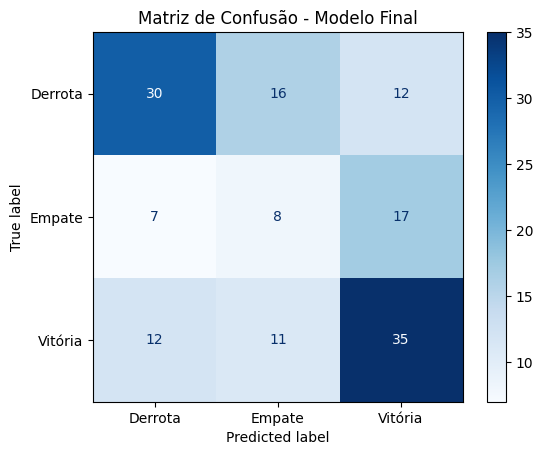

In [40]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Derrota', 'Empate', 'Vitória'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final')
plt.show()

#### SVC